# Programming Assignment 1: Recommender System
### Coure: CS373
#### Developer 1: Jalin A. Brown
#### Developer 2: Sandeep Durga
#### File: 02_cluster_knn.ipynb

### Part One: Data Setup and User-Based Collaborative Filtering

3. Apply K-means clustering to users
- Cluster users based on their rating vectors using K-means
- Use K-means++ to find the initial centroids of clusters
- Choose the first centroid randomly
- Clearly explain how you chose the number of clusters and why you think
it will work?
- Handle missing values by filling with user means before clustering
- Assign each user to their closest cluster

4. Build cluster-based KNN recommender
- For target users, identify their cluster
- Use other users in same cluster as neighbors for prediction
- Predict ratings

5. Evaluate CF performance:
- Calculate RMSE on test set for each model and k value combination
- Create line plot: number of clusters on x-axis, RMSE on y-axis
- Create results table showing best performing configuration

In [73]:
import os
os.environ["OMP_NUM_THREADS"] = "4"                    # turn off thread warnings

!pip install import_ipynb

import import_ipynb   # import the module first
import data_and_knn

import numpy as np                                     # math
import pandas as pd                                    # user-item matrix
import matplotlib.pyplot as plt                        # Plot RMSE for clusters

from sklearn.cluster import KMeans                     # K means
from sklearn.preprocessing import StandardScaler       # Standardize user vectors
from sklearn.metrics.pairwise import cosine_similarity # pairwise similarity between users
from sklearn.metrics import mean_squared_error,root_mean_squared_error

from sqlalchemy.sql.functions import current_user

In [74]:
# Import the MovieLens 100k training and test data sets
# Currently using the first fold split of data of user.base computed as u1_base and u1_test
u1_base_mat = pd.read_csv("../data/u1.base", names=["user_id","item_id","rating","timestamp"], sep="\t", )
u1_test_mat = pd.read_csv("../data/u1.test", names=["user_id","item_id","rating","timestamp"], sep="\t")
print(u1_base_mat.head())
print(f"\nTraining data shape: {u1_base_mat.shape}\n")


print(u1_test_mat.head())
print(f"\nTest data shape: {u1_test_mat.shape}\n")

   user_id  item_id  rating  timestamp
0        1        1       5  874965758
1        1        2       3  876893171
2        1        3       4  878542960
3        1        4       3  876893119
4        1        5       3  889751712

Training data shape: (80000, 4)

   user_id  item_id  rating  timestamp
0        1        6       5  887431973
1        1       10       3  875693118
2        1       12       5  878542960
3        1       14       5  874965706
4        1       17       3  875073198

Test data shape: (20000, 4)



In [75]:
# Create user-item matrix (excluding possible duplicates or non integers)
users = u1_base_mat["user_id"].astype(int).unique()
items = u1_base_mat["item_id"].astype(int).unique()
user_item_training_matrix = pd.DataFrame(np.nan, index=users, columns=items)

# Fill cells with ratings
for row in u1_base_mat.itertuples(index = False):
    user_item_training_matrix.loc[row.user_id, row.item_id] = row.rating

user_item_training_matrix

,1,2,3,4,5,7,8,9,11,13,...,1674,1675,1676,1677,1678,1679,1680,907,1681,1682
1,5.0,3.0,4.0,3.0,3.0,4.0,1.0,5.0,2.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
939,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
940,NaN,NaN,NaN,2.0,NaN,4.0,5.0,3.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
941,5.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3: Apply K-means clustering to users

In [76]:
#  Handle missing values by NaN entries with the user's average rating from other items
user_means_mat = user_item_training_matrix.mean(axis=1)
filled_user_means_mat = user_item_training_matrix.T.fillna(user_means_mat).T
print(filled_user_means_mat)

         1         2         3         4         5         7         8     \
1    5.000000  3.000000  4.000000  3.000000  3.000000  4.000000  1.000000   
2    4.000000  3.800000  3.800000  3.800000  3.800000  3.800000  3.800000   
3    3.000000  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000   
4    4.357143  4.357143  4.357143  4.357143  4.357143  4.357143  4.357143   
5    2.956044  2.956044  2.956044  2.956044  2.956044  2.956044  2.956044   
..        ...       ...       ...       ...       ...       ...       ...   
939  4.265306  4.265306  4.265306  4.265306  4.265306  4.265306  4.265306   
940  3.457944  3.457944  3.457944  2.000000  3.457944  4.000000  5.000000   
941  5.000000  4.045455  4.045455  4.045455  4.045455  4.000000  4.045455   
942  4.265823  4.265823  4.265823  4.265823  4.265823  4.265823  4.265823   
943  3.410714  5.000000  3.410714  3.410714  3.410714  3.410714  3.410714   

         9         11        13    ...      1674      1675      1676  \
1  

In [77]:
# Normalize user vectors using Z-score to apply Euclidean distance in K means
user_means = filled_user_means_mat.mean(axis=1)
user_stds = filled_user_means_mat.std(axis=1).replace(0, 1) # prevent divide by 0

zscore_mat = filled_user_means_mat.sub(user_means, axis=0).div(user_stds, axis=0)

print("z_mat shape:", zscore_mat.shape)
print(zscore_mat)

z_mat shape: (943, 1650)
             1             2             3             4             5     \
1    3.615543e+00 -1.868708e+00  8.734178e-01 -1.868708e+00 -1.868708e+00   
2    1.310614e+00  5.820294e-15  5.820294e-15  5.820294e-15  5.820294e-15   
3    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
4    9.921760e-15  9.921760e-15  9.921760e-15  9.921760e-15  9.921760e-15   
5    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
..            ...           ...           ...           ...           ...   
939  5.343939e-15  5.343939e-15  5.343939e-15  5.343939e-15  5.343939e-15   
940  0.000000e+00  0.000000e+00  0.000000e+00 -5.682177e+00  0.000000e+00   
941  9.413776e+00 -8.759261e-15 -8.759261e-15 -8.759261e-15 -8.759261e-15   
942  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
943  1.108500e-15  3.967049e+00  1.108500e-15  1.108500e-15  1.108500e-15   

             7             8             9        

####  Elbow method for Kmeans++ to choose best number of clusters
- Cluster users by their normalized rating vectors
- Initialize kmeans++ with first centroid chosen randomly
- Remaining centroids are calculated by distance
- Plot several cluster counts using elbow method to choose best k
- Assign each user to their closest cluster centroid

C:\Users\dasas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\dasas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\dasas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
C:\Users\dasas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

k= 1  SSE=1524638.90
k= 2  SSE=1508609.20
k= 3  SSE=1496967.54
k= 4  SSE=1487482.59
k= 5  SSE=1479447.10
k= 6  SSE=1476690.07
k= 7  SSE=1466983.49
k= 8  SSE=1462368.32
k= 9  SSE=1457247.13


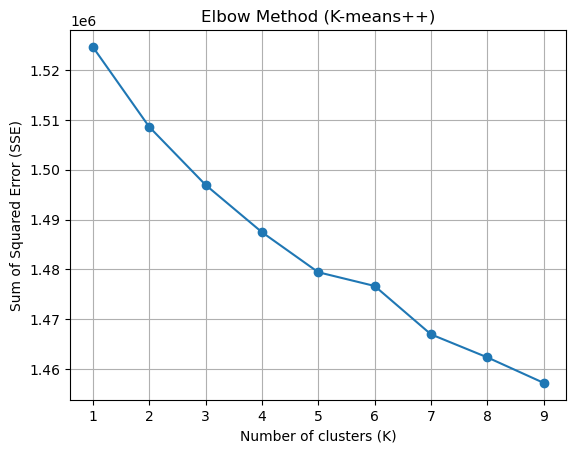

In [78]:
os.environ["OMP_NUM_THREADS"] = "4" # turn off warnings for threads
k_values = [1, 2, 3, 4, 5, 6, 7, 8, 9]
sum_square_errors = []

for k in k_values:
    km = KMeans(n_clusters=k, init="k-means++", n_init="auto", random_state=0)
    km.fit(zscore_mat)
    sum_square_errors.append(km.inertia_)  # inertia_ is SSE

for k, v in zip(k_values, sum_square_errors):
    print(f"k={k:2d}  SSE={v:.2f}")

plt.figure()
plt.plot(k_values, sum_square_errors, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Sum of Squared Error (SSE)")
plt.title("Elbow Method (K-means++)")
plt.grid(True)
plt.show()

#### Based on the elbow plot, the decrease in SSE elbows out around 5 clusters. Therefore our chosen k will be 5.

So fit K means with K=5 for K means++ on the normalized user vectors and assign each user to a cluster

In [79]:
# Create clusters with first centroid random
cluster_count = 5
kmeans = KMeans(n_clusters=cluster_count, init="k-means++", n_init="auto", random_state=0)

# Fit to normalized user vectors and get cluster labels
user_cluster_labels = kmeans.fit_predict(zscore_mat)

# Map each user id to cluster id
user_clusters_mat = pd.Series(user_cluster_labels, index=zscore_mat.index, name="user_clusters")

print("Users per cluster:")
print(user_clusters_mat.value_counts().sort_index())

print("User cluster matrix:")
print(user_clusters_mat)


Users per cluster:
user_clusters
0    193
1    290
2    109
3    109
4    242
Name: count, dtype: int64
User cluster matrix:
1      4
2      1
3      1
4      3
5      4
      ..
939    0
940    3
941    3
942    4
943    4
Name: user_clusters, Length: 943, dtype: int32


C:\Users\dasas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


# Build cluster-based KNN

In [80]:
# Choose target user and unrated item
current_user = 943

k_neighbors = [1, 3, 5, 7, 10]

# Label target user's cluster
current_cluster_id = user_clusters_mat.loc[current_user]
print(f"User {current_user} is in cluster: {current_cluster_id}")

# Identify the members of this cluster
cluster_members = user_clusters_mat[user_clusters_mat == current_cluster_id].index
print(f"Current cluster size: {len(cluster_members)} members")

# Use og rating matrix to create cluster sim matrix
current_cluster_mat = user_item_training_matrix.loc[cluster_members]
filled_current_cluster_mat = current_cluster_mat.fillna(0)

# Compute cosine similarity among cluster members
current_cluster_similarity_mat = pd.DataFrame(cosine_similarity(filled_current_cluster_mat), index=cluster_members, columns=cluster_members)

# Similarities between this user and all other users
similarities_to_others = current_cluster_similarity_mat[current_user].drop(index=current_user)
pos_sim = similarities_to_others[similarities_to_others > 0.0].sort_values(ascending=False)

print(f"Top similar users for user {current_user} within cluster {current_cluster_id}:\n")
for k in k_neighbors:
    top_k = pos_sim.head(k)
    print(f"K = {k}:")
    print(top_k)
    print("-"*40)

print(current_cluster_similarity_mat)

User 943 is in cluster: 4
Current cluster size: 242 members
Top similar users for user 943 within cluster 4:

K = 1:
682    0.547608
Name: 943, dtype: float64
----------------------------------------
K = 3:
682    0.547608
933    0.509386
709    0.493219
Name: 943, dtype: float64
----------------------------------------
K = 5:
682    0.547608
933    0.509386
709    0.493219
472    0.488882
864    0.488014
Name: 943, dtype: float64
----------------------------------------
K = 7:
682    0.547608
933    0.509386
709    0.493219
472    0.488882
864    0.488014
632    0.485980
886    0.480789
Name: 943, dtype: float64
----------------------------------------
K = 10:
682    0.547608
933    0.509386
709    0.493219
472    0.488882
864    0.488014
632    0.485980
886    0.480789
715    0.479110
618    0.478501
896    0.476132
Name: 943, dtype: float64
----------------------------------------
          1         5         9         13        22        37        42   \
1    1.000000  0.193545  0

#### Predict ratings using weighted average
( with neighbors of the same cluster)

In [81]:
# Choose a target example
target_user = 943
target_item = 1
k_value = 5

# Gather k most similar neighbors who have rated the target item
pos_sim = current_cluster_similarity_mat[target_user].drop(index=target_user)
pos_sim = pos_sim[pos_sim > 0.0].sort_values(ascending=False)
top_k = pos_sim.head(k_value)

numerator = 0.0
denominator = 0.0

for neighbor, sim in top_k.items():
    neighbor_rating = current_cluster_mat.loc[neighbor, target_item]
    if not np.isnan(neighbor_rating):
        numerator += neighbor_rating * sim
        denominator += abs(sim)
if denominator == 0:
    print(f"No similar users for user {target_user} rated {target_item}.")
    predicted_rating = np.nan
else:
    predicted_rating = numerator / denominator
    print(f"Using K value {k_value}, the predicted rating for user {target_user} on item {target_item} is {predicted_rating:.2f}.")


Using K value 5, the predicted rating for user 943 on item 1 is 4.18.


#### ^ All code up to this point written by Jalin A. Brown ^

#### v All code from this point below written by Durga Sandeep v

#### Evaluate CF performance
- Calculate RMSE on test set for each model and k value combo
- Create line plot: number of clusters on x-axis, RMSE on y-axis
- Create results table showing best performing config

#### Plot RMSE vs number of clusters

#### Using Test Data Set

In [82]:
print(u1_test_mat.head())
print(f"\nTest data shape: {u1_test_mat.shape}\n")

   user_id  item_id  rating  timestamp
0        1        6       5  887431973
1        1       10       3  875693118
2        1       12       5  878542960
3        1       14       5  874965706
4        1       17       3  875073198

Test data shape: (20000, 4)



#### If the returned value is False, it means there are no missing values in the test dataset.

In [83]:
u1_test_mat.isna().any().any()

False

In [84]:
u1_test_mat.isna().sum()

user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64

In [85]:
# Pivot the test dataset to create a matrix with only actual ratings
user_item_test_matrix = u1_test_mat.pivot(index='user_id', columns='item_id', values='rating')

user_item_test_matrix

item_id,1,2,3,4,5,6,7,8,9,10,...,1555,1557,1561,1562,1563,1565,1578,1582,1586,1591
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
458,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Analyze Sparsity

In [86]:
# Create the user-item matrix
user_count = user_item_test_matrix.shape[0]
item_count = user_item_test_matrix.shape[1]
mat_size = user_count * item_count
present = user_item_test_matrix.count().sum()
missing = mat_size - present
sparsity = (missing / mat_size) * 100

print(f"sparsity: {sparsity:.2f}%")

sparsity: 96.91%


### Build KNN Recommender:

- Full similarity space with Nan set to 0
- Only keep users with cosine_similarity > 0 (positive relationship)

In [87]:
# Fill missing ratings with 0 for cosine similarity
user_item_test_matrix_filled = user_item_test_matrix.fillna(0)

# Compute cosine similarity between all users
cosine_sim_mat2 = cosine_similarity(user_item_test_matrix_filled)
cosine_sim_matrix2 = pd.DataFrame(cosine_sim_mat2, index=user_item_test_matrix_filled.index, columns=user_item_test_matrix_filled.index)

cosine_sim_matrix2.head()


user_id,1,2,3,4,5,6,7,8,9,10,...,452,453,454,455,456,457,458,459,460,462
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.000000,0.015980,0.016475,0.191021,0.228348,0.228966,0.122233,0.040452,0.124528,...,0.028332,0.093821,0.034423,0.0,0.057729,0.0,0.000000,0.0,0.068305,0.0
2,0.000000,1.000000,0.084814,0.187367,0.000000,0.047720,0.023986,0.104676,0.061342,0.017167,...,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0
3,0.015980,0.084814,1.000000,0.157433,0.000000,0.036378,0.056075,0.018684,0.000000,0.010469,...,0.000000,0.000000,0.000000,0.0,0.023727,0.0,0.000000,0.0,0.000000,0.0
4,0.016475,0.187367,0.157433,1.000000,0.000000,0.048754,0.040215,0.128414,0.000000,0.026983,...,0.000000,0.000000,0.000000,0.0,0.061153,0.0,0.000000,0.0,0.000000,0.0
5,0.191021,0.000000,0.000000,0.000000,1.000000,0.100912,0.164160,0.105230,0.000000,0.117047,...,0.044049,0.056925,0.030105,0.0,0.000000,0.0,0.061314,0.0,0.000000,0.0


In [88]:
# Select the target user
current_user1 = 5

# Select a value of K
K_values1 = [1, 3, 5, 7, 10]

# Extract similarities between this user and all other users
similarities_to_others1 = cosine_sim_matrix2[current_user1].copy()
similarities_to_others1 = similarities_to_others.drop(index=current_user1)
pos_sim1 = similarities_to_others1[similarities_to_others1 > 0.0].sort_values(ascending=False)

print(f"Top similar users for user {current_user1} with varying K:\n")
for k in K_values1:
    top_k1 = pos_sim1.head(k)
    print(f"K = {k}:")
    print(top_k)
    print("-"*40)

Top similar users for user 5 with varying K:

K = 1:
682    0.547608
933    0.509386
709    0.493219
472    0.488882
864    0.488014
Name: 943, dtype: float64
----------------------------------------
K = 3:
682    0.547608
933    0.509386
709    0.493219
472    0.488882
864    0.488014
Name: 943, dtype: float64
----------------------------------------
K = 5:
682    0.547608
933    0.509386
709    0.493219
472    0.488882
864    0.488014
Name: 943, dtype: float64
----------------------------------------
K = 7:
682    0.547608
933    0.509386
709    0.493219
472    0.488882
864    0.488014
Name: 943, dtype: float64
----------------------------------------
K = 10:
682    0.547608
933    0.509386
709    0.493219
472    0.488882
864    0.488014
Name: 943, dtype: float64
----------------------------------------


In [89]:
users3, items3, ratings3 = [], [], []

for user in user_item_test_matrix.index:
    for item in user_item_test_matrix.columns:
        rating = user_item_test_matrix.loc[user, item]
        if not np.isnan(rating):  # Only keep existing ratings
            users3.append(user)
            items3.append(item)
            ratings3.append(rating)

# Convert to numpy arrays if needed
users = np.array(users3)
items = np.array(items3)
ratings = np.array(ratings3)

print(users3[:5], items3[:5], ratings3[:5])

[1, 1, 1, 1, 1] [6, 10, 12, 14, 17] [5.0, 3.0, 5.0, 5.0, 3.0]


In [90]:
predicted_ratings = []

k_value1 = 5

for u, i in zip(users, items):
    # Get top-k similar users to target user
    pos_sim1 = cosine_sim_matrix2[u].drop(index=u)
    pos_sim1 = pos_sim1[pos_sim1 > 0.0].sort_values(ascending=False)
    top_k1 = pos_sim1.head(k_value1)

    numerator1 = 0.0
    denominator1 = 0.0

    for neighbor1, sim1 in top_k1.items():
        neighbor_rating1 = user_item_test_matrix_filled.loc[neighbor1, i]
        if not np.isnan(neighbor_rating1):
            numerator1 += neighbor_rating1 * sim1
            denominator1 += abs(sim1)

    if denominator1 == 0:
        predicted_ratings.append(np.nan)
    else:
        predicted_ratings.append(numerator1 / denominator1)

predicted_ratings = np.array(predicted_ratings)
print(predicted_ratings[:10])


[0.         0.85622533 1.87335397 1.07028166 0.40153615 0.
 2.07412205 1.36273939 0.         2.95721898]


In [91]:
rmse = np.sqrt(np.mean((ratings - predicted_ratings) ** 2))
print(f"RMSE: {rmse:.4f}")

RMSE: 2.8417


## Apply K-means

In [92]:
users = u1_test_mat["user_id"].astype(int).unique()
items = u1_test_mat["item_id"].astype(int).unique()
user_item_testing_matrix = pd.DataFrame(np.nan, index=users, columns=items)

# Fill cells with ratings
for row in u1_test_mat.itertuples(index = False):
    user_item_testing_matrix.loc[row.user_id, row.item_id] = row.rating

user_item_testing_matrix

user_test_means_mat = user_item_testing_matrix.mean(axis=1)
filled_user_means_test_mat = user_item_testing_matrix.T.fillna(user_test_means_mat).T
print(filled_user_means_test_mat)

         6         10        12        14        17        20        23    \
1    5.000000  3.000000  5.000000  5.000000  3.000000  4.000000  4.000000   
2    3.545455  3.545455  3.545455  3.545455  3.545455  3.545455  3.545455   
3    2.576923  2.576923  2.576923  2.576923  2.576923  2.576923  2.576923   
4    4.300000  4.300000  4.300000  4.300000  4.300000  4.300000  4.300000   
5    2.785714  2.785714  2.785714  2.785714  4.000000  2.785714  2.785714   
..        ...       ...       ...       ...       ...       ...       ...   
457  4.000000  4.000000  4.000000  4.000000  4.000000  4.000000  4.000000   
458  4.000000  4.000000  4.000000  4.000000  4.000000  4.000000  4.000000   
459  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000   
460  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000  3.000000   
462  5.000000  5.000000  5.000000  5.000000  5.000000  5.000000  5.000000   

         24        27        31    ...      1565      1578      1582  \
1  

In [93]:
# Normalize user vectors using Z-score to apply Euclidean distance in K means
user_test_means = filled_user_means_test_mat.mean(axis=1)
user_test_stds = filled_user_means_test_mat.std(axis=1).replace(0, 1) # prevent divide by 0

zscore_test_mat = filled_user_means_test_mat.sub(user_test_means, axis=0).div(user_test_stds, axis=0)

print("z_mat shape:", zscore_test_mat.shape)
print(zscore_test_mat)

z_mat shape: (459, 1410)
             6             10            12            14            17    \
1    3.763285e+00 -1.392415e+00  3.763285e+00  3.763285e+00 -1.392415e+00   
2   -3.304023e-15 -3.304023e-15 -3.304023e-15 -3.304023e-15 -3.304023e-15   
3    0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
4    1.349866e-14  1.349866e-14  1.349866e-14  1.349866e-14  1.349866e-14   
5    1.378913e-15  1.378913e-15  1.378913e-15  1.378913e-15  3.770401e+00   
..            ...           ...           ...           ...           ...   
457  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
458  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
459  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
460  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
462  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   

             20            23            24       

In [94]:
users4, items4, ratings4 = [], [], []

for user in user_item_testing_matrix.index:
    for item in user_item_testing_matrix.columns:
        rating = user_item_testing_matrix.loc[user, item]
        if not np.isnan(rating):  # Only keep existing ratings
            users4.append(user)
            items4.append(item)
            ratings4.append(rating)

# Convert to numpy arrays if needed
users = np.array(users4)
items = np.array(items4)
ratings = np.array(ratings4)

print(users4[:5], items4[:5], ratings4[:5])

[1, 1, 1, 1, 1] [6, 10, 12, 14, 17] [5.0, 3.0, 5.0, 5.0, 3.0]


In [95]:
predicted_ratings = []

k_value = 5

for u, i in zip(users, items):
    try:
        # Get top-k similar users to target user
        # Check if user exists in similarity matrix
        if u in current_cluster_similarity_mat.index:
            pos_sim = current_cluster_similarity_mat[u].drop(index=u)
            pos_sim = pos_sim[pos_sim > 0.0].sort_values(ascending=False)
            top_k = pos_sim.head(k_value)

            numerator = 0.0
            denominator = 0.0

            for neighbor, sim in top_k.items():
                # Check if neighbor and item exist in rating matrix
                if neighbor in current_cluster_mat.index and i in current_cluster_mat.columns:
                    neighbor_rating = current_cluster_mat.loc[neighbor, i]
                    if not np.isnan(neighbor_rating):
                        numerator += neighbor_rating * sim
                        denominator += abs(sim)

            if denominator == 0:
                predicted_ratings.append(np.nan)
            else:
                predicted_ratings.append(numerator / denominator)
        else:
            # If user doesn't exist, append NaN
            predicted_ratings.append(np.nan)
    except KeyError:
        # Handle any KeyError by appending NaN
        predicted_ratings.append(np.nan)

predicted_ratings = np.array(predicted_ratings)
print(predicted_ratings[:10])

[       nan 4.         5.         3.         1.99820485        nan
 3.         3.74801832 4.         3.51392663]


Evaluating User-based CF...
User-based CF, K=3 → RMSE=1.2845
User-based CF, K=5 → RMSE=1.2508
User-based CF, K=7 → RMSE=1.2166
User-based CF, K=10 → RMSE=1.1866

Evaluating Cluster-based CF...


C:\Users\dasas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Cluster-based CF, Clusters=2, K=3 → RMSE=1.2024
Cluster-based CF, Clusters=2, K=5 → RMSE=1.1676
Cluster-based CF, Clusters=2, K=7 → RMSE=1.1413
Cluster-based CF, Clusters=2, K=10 → RMSE=1.1166


C:\Users\dasas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Cluster-based CF, Clusters=3, K=3 → RMSE=1.1778
Cluster-based CF, Clusters=3, K=5 → RMSE=1.1399
Cluster-based CF, Clusters=3, K=7 → RMSE=1.1238
Cluster-based CF, Clusters=3, K=10 → RMSE=1.1116


C:\Users\dasas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Cluster-based CF, Clusters=5, K=3 → RMSE=1.2202
Cluster-based CF, Clusters=5, K=5 → RMSE=1.1761
Cluster-based CF, Clusters=5, K=7 → RMSE=1.1514
Cluster-based CF, Clusters=5, K=10 → RMSE=1.1287


C:\Users\dasas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


Cluster-based CF, Clusters=7, K=3 → RMSE=1.2158
Cluster-based CF, Clusters=7, K=5 → RMSE=1.1726
Cluster-based CF, Clusters=7, K=7 → RMSE=1.1513
Cluster-based CF, Clusters=7, K=10 → RMSE=1.1286


,Model,K,Clusters,RMSE
0,User-based CF,3,NaN,1.284520
1,User-based CF,5,NaN,1.250783
2,User-based CF,7,NaN,1.216607
3,User-based CF,10,NaN,1.186614
4,Cluster-based CF,3,2.0,1.202355
5,Cluster-based CF,5,2.0,1.167587
6,Cluster-based CF,7,2.0,1.141337
7,Cluster-based CF,10,2.0,1.116591
8,Cluster-based CF,3,3.0,1.177776
9,Cluster-based CF,5,3.0,1.139888


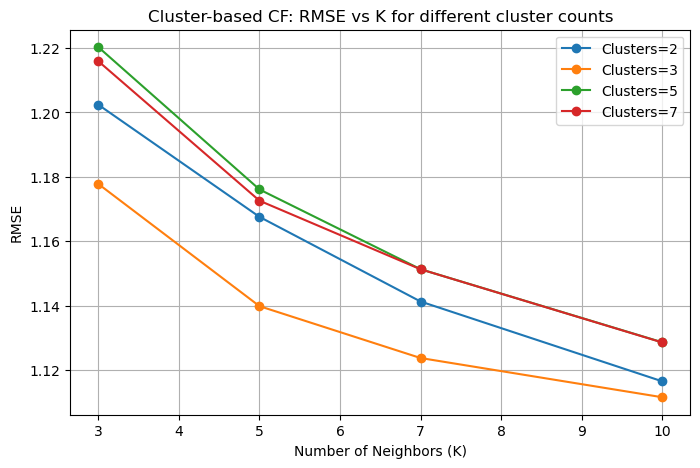


 Best Performing Configuration:
Model       Cluster-based CF
K                         10
Clusters                 3.0
RMSE                1.111644
Name: 11, dtype: object


In [96]:

# --- Functions for prediction ---

def predict_user_based(user_id, item_id, sim_matrix, rating_matrix, k):
    sim_scores = sim_matrix.loc[user_id].drop(index=user_id)
    sim_scores = sim_scores[sim_scores > 0.0].sort_values(ascending=False)
    top_k = sim_scores.head(k)

    num, den = 0.0, 0.0
    for neighbor, sim in top_k.items():
        neighbor_rating = rating_matrix.loc[neighbor, item_id]
        if not np.isnan(neighbor_rating):
            num += neighbor_rating * sim
            den += abs(sim)
    return np.nan if den == 0 else num / den


def predict_cluster_based(user_id, item_id, user_clusters, rating_matrix, k):
    cluster_id = user_clusters[user_id]
    cluster_members = user_clusters[user_clusters == cluster_id].index
    cluster_mat = rating_matrix.loc[cluster_members].fillna(0)

    cluster_sim = pd.DataFrame(cosine_similarity(cluster_mat),
                               index=cluster_members,
                               columns=cluster_members)
    sim_scores = cluster_sim.loc[user_id].drop(index=user_id)
    sim_scores = sim_scores[sim_scores > 0.0].sort_values(ascending=False)
    top_k = sim_scores.head(k)

    num, den = 0.0, 0.0
    for neighbor, sim in top_k.items():
        neighbor_rating = rating_matrix.loc[neighbor, item_id]
        if not np.isnan(neighbor_rating):
            num += neighbor_rating * sim
            den += abs(sim)
    return np.nan if den == 0 else num / den


# --- Parameters ---
k_values = [3, 5, 7, 10]
cluster_counts = [2, 3, 5, 7]   # different cluster numbers to test

results = []

# Pre-fill missing ratings with user means for K-means clustering
user_means = user_item_training_matrix.mean(axis=1)
filled_user_means_mat = user_item_training_matrix.T.fillna(user_means).T

# Normalize for clustering
user_stds = filled_user_means_mat.std(axis=1).replace(0, 1)
zscore_mat = filled_user_means_mat.sub(user_means, axis=0).div(user_stds, axis=0)

# --- User-based CF only needs k loop ---
print("Evaluating User-based CF...")
for k in k_values:
    true_ratings = []
    predicted_ratings = []

    for row in u1_test_mat.itertuples(index=False):
        user_id, item_id, true_rating = row.user_id, row.item_id, row.rating

        if user_id not in user_item_training_matrix.index or item_id not in user_item_training_matrix.columns:
            continue

        pred = predict_user_based(user_id, item_id, cosine_sim_matrix2, user_item_training_matrix, k)
        if not np.isnan(pred):
            true_ratings.append(true_rating)
            predicted_ratings.append(pred)

    rmse = root_mean_squared_error(true_ratings, predicted_ratings)
    results.append({"Model": "User-based CF", "K": k, "Clusters": None, "RMSE": rmse})
    print(f"User-based CF, K={k} → RMSE={rmse:.4f}")


# --- Cluster-based CF: loop over k and cluster_count ---
print("\nEvaluating Cluster-based CF...")
for cluster_count in cluster_counts:
    kmeans = KMeans(n_clusters=cluster_count, init="k-means++", n_init="auto", random_state=0)
    user_cluster_labels = kmeans.fit_predict(zscore_mat)
    user_clusters_mat = pd.Series(user_cluster_labels, index=zscore_mat.index, name="cluster")

    for k in k_values:
        true_ratings = []
        predicted_ratings = []

        for row in u1_test_mat.itertuples(index=False):
            user_id, item_id, true_rating = row.user_id, row.item_id, row.rating

            if user_id not in user_item_training_matrix.index or item_id not in user_item_training_matrix.columns:
                continue

            pred = predict_cluster_based(user_id, item_id, user_clusters_mat, user_item_training_matrix, k)
            if not np.isnan(pred):
                true_ratings.append(true_rating)
                predicted_ratings.append(pred)

        rmse = root_mean_squared_error(true_ratings, predicted_ratings)
        results.append({"Model": "Cluster-based CF", "K": k, "Clusters": cluster_count, "RMSE": rmse})
        print(f"Cluster-based CF, Clusters={cluster_count}, K={k} → RMSE={rmse:.4f}")


# --- Convert results to DataFrame ---
results_df = pd.DataFrame(results)
display(results_df)

# --- Plot RMSE vs K for Cluster-based CF (different cluster counts) ---
plt.figure(figsize=(8, 5))
for cluster_count in cluster_counts:
    subset = results_df[(results_df["Model"] == "Cluster-based CF") & (results_df["Clusters"] == cluster_count)]
    plt.plot(subset["K"], subset["RMSE"], marker='o', label=f"Clusters={cluster_count}")

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("RMSE")
plt.title("Cluster-based CF: RMSE vs K for different cluster counts")
plt.legend()
plt.grid(True)
plt.show()

# --- Show best performing configuration overall ---
best_row = results_df.loc[results_df["RMSE"].idxmin()]
print("\n Best Performing Configuration:")
print(best_row)


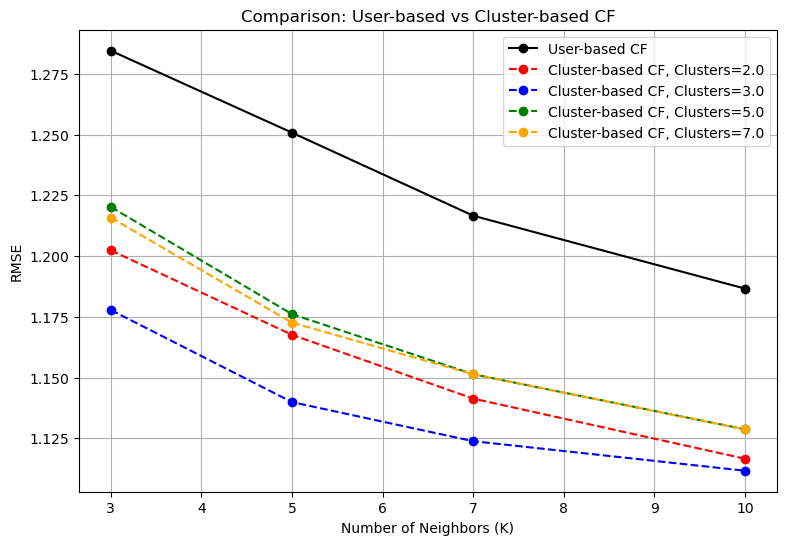

In [97]:

plt.figure(figsize=(9, 6))

# Plot User-based CF RMSE
user_based = results_df[results_df["Model"] == "User-based CF"]
plt.plot(user_based["K"], user_based["RMSE"], marker='o', linestyle='-', color='black', label='User-based CF')

# Plot Cluster-based CF RMSE for each cluster count
cluster_counts = results_df["Clusters"].dropna().unique()
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, cluster_count in enumerate(sorted(cluster_counts)):
    subset = results_df[(results_df["Model"] == "Cluster-based CF") & (results_df["Clusters"] == cluster_count)]
    plt.plot(subset["K"], subset["RMSE"], marker='o', linestyle='--', color=colors[i % len(colors)],
             label=f'Cluster-based CF, Clusters={cluster_count}')

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("RMSE")
plt.title("Comparison: User-based vs Cluster-based CF")
plt.grid(True)
plt.legend()
plt.show()
